# **Pertanyaan Bisnis**
1. Faktor risiko apa yang perlu diprioritaskan oleh aplikasi PERISAI untuk diberikan rekomendasi perubahan gaya hidup?
2. Variabel kesehatan dan perilaku apa yang memiliki hubungan paling kuat dengan risiko Diabetes, Hipertensi, dan Kolesterol Tinggi?
3. Apakah log aktivitas harian pengguna dapat dikonversi menjadi fitur yang kompatibel dengan dataset prediksi risiko PTM?

# **Import Library**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import pickle
import os

sns.set_theme(style="whitegrid")

# **Data Wrangling**

## Gathering Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/salschoco2711/diabetes-brfss/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## **Data Dictionary**

Dataset utama bersumber dari **BRFSS 2015** (Behavioral Risk Factor Surveillance System) dengan format 50/50 split untuk kelas Diabetes. Berikut penjelasan setiap kolom:

### Target / Label

| Kolom | Tipe | Nilai | Deskripsi |
|---|---|---|---|
| `Diabetes_binary` | Biner | 0 = Tidak, 1 = Ya | Status diagnosis diabetes (target utama, balanced 50:50) |
| `HighBP` | Biner | 0 = Tidak, 1 = Ya | Riwayat hipertensi / tekanan darah tinggi |
| `HighChol` | Biner | 0 = Tidak, 1 = Ya | Riwayat kolesterol tinggi |

### Fitur Klinis & Demografis

| Kolom | Tipe | Nilai | Deskripsi |
|---|---|---|---|
| `BMI` | Kontinu | ~15–98 | Body Mass Index, dihitung dari berat dan tinggi badan |
| `Age` | Ordinal | 1–13 | Kategori usia (1 = 18–24 th, ..., 13 = 80+ th) |
| `GenHlth` | Ordinal | 1–5 | Penilaian kesehatan umum secara subjektif (1 = Sangat Baik, 5 = Buruk) |
| `MentHlth` | Kontinu | 0–30 | Jumlah hari dalam 30 hari terakhir di mana kesehatan mental buruk |
| `PhysHlth` | Kontinu | 0–30 | Jumlah hari dalam 30 hari terakhir di mana kesehatan fisik buruk |
| `Education` | Ordinal | 1–6 | Tingkat pendidikan tertinggi yang ditamatkan |
| `Income` | Ordinal | 1–8 | Kategori pendapatan rumah tangga tahunan |
| `Stroke` | Biner | 0 = Tidak, 1 = Ya | Riwayat stroke |
| `HeartDiseaseorAttack` | Biner | 0 = Tidak, 1 = Ya | Riwayat penyakit jantung koroner atau serangan jantung |
| `DiffWalk` | Biner | 0 = Tidak, 1 = Ya | Kesulitan berjalan atau menaiki tangga |

### Fitur Gaya Hidup

| Kolom | Tipe | Nilai | Deskripsi |
|---|---|---|---|
| `PhysActivity` | Biner | 0 = Tidak, 1 = Ya | Melakukan aktivitas fisik dalam 30 hari terakhir (di luar pekerjaan) |
| `Smoker` | Biner | 0 = Tidak, 1 = Ya | Pernah merokok minimal 100 batang sepanjang hidup |
| `HvyAlcoholConsump` | Biner | 0 = Tidak, 1 = Ya | Konsumsi alkohol berlebihan (>14 minuman/minggu untuk pria, >7 untuk wanita) |
| `Fruits` | Biner | 0 = Tidak, 1 = Ya | Mengonsumsi buah minimal sekali sehari |
| `Veggies` | Biner | 0 = Tidak, 1 = Ya | Mengonsumsi sayur minimal sekali sehari |
| `CholCheck` | Biner | 0 = Tidak, 1 = Ya | Melakukan cek kolesterol dalam 5 tahun terakhir |
| `AnyHealthcare` | Biner | 0 = Tidak, 1 = Ya | Memiliki akses ke layanan kesehatan |
| `NoDocbcCost` | Biner | 0 = Tidak, 1 = Ya | Pernah tidak bisa ke dokter karena biaya |

### Fitur Rekayasa (Feature Engineering)

| Kolom | Tipe | Nilai | Deskripsi |
|---|---|---|---|
| `SleepHours` | Kontinu | 4–11 jam | Estimasi durasi tidur harian; dibuat dari pemetaan kategori `Age` ke rata-rata tidur berdasarkan literatur, ditambah noise Gaussian (std=0.8). **Bukan fitur asli BRFSS.** |

> **Catatan:** Kolom `Diabetes_binary` (asli BRFSS) digantikan oleh kolom `Diabetes` yang di-*regenerate* ulang melalui scoring rule berbasis kombinasi fitur klinis, untuk konsistensi dengan target `HighBP` dan `HighChol` dalam pipeline multi-label.

## Assessing Data

In [3]:
print("--- Info Dataset ---")
df.info()

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15

In [4]:
print("\n--- Jumlah Missing Values ---")
print(df.isnull().sum())


--- Jumlah Missing Values ---
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [5]:
print("\n--- Jumlah Data Duplikat ---")
print(df.duplicated().sum())


--- Jumlah Data Duplikat ---
1635


### Rangkuman Asessing Data
* Tidak ditemukan missing values pada data
* Terdapat data duplikat sebanyak 1635

## Cleaning Data

In [6]:
df_clean = df.drop_duplicates().copy()

In [7]:
target_ptm = ['Diabetes_binary', 'HighBP', 'HighChol']
df_clean[target_ptm] = df_clean[target_ptm].astype(int)

In [8]:
kolom_biner = ['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']
df_clean[kolom_biner] = df_clean[kolom_biner].astype(int)

In [9]:
print("Ukuran data setelah dibersihkan:", df_clean.shape)

Ukuran data setelah dibersihkan: (69057, 22)


# **Exploratory Data Analysis**

## Statistik Deskriptif

In [10]:
print("Prevalensi Penyakit Tidak Menular:")
for penyakit in target_ptm:
    persen = df_clean[penyakit].value_counts(normalize=True) * 100
    print(f"- {penyakit}: {persen[1]:.2f}% Terdiagnosis")

Prevalensi Penyakit Tidak Menular:
- Diabetes_binary: 50.82% Terdiagnosis
- HighBP: 57.12% Terdiagnosis
- HighChol: 53.13% Terdiagnosis


In [11]:
print("\nRata-rata BMI per kategori penyakit:")
print(df_clean.groupby('Diabetes_binary')['BMI'].mean())
print(df_clean.groupby('HighBP')['BMI'].mean())
print(df_clean.groupby('HighChol')['BMI'].mean())


Rata-rata BMI per kategori penyakit:
Diabetes_binary
0    27.880183
1    31.964242
Name: BMI, dtype: float64
HighBP
0    28.038703
1    31.394884
Name: BMI, dtype: float64
HighChol
0    29.012730
1    30.787719
Name: BMI, dtype: float64


# **Visualization & Explanatory Analysis**

## Visualisasi Distribusi Target Penyakit Tidak Menular

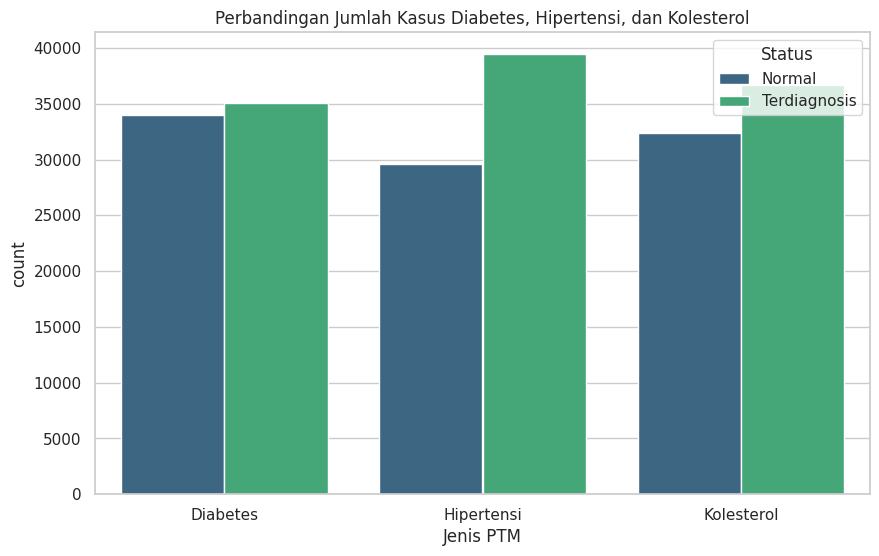

In [12]:
plt.figure(figsize=(10, 6))
df_melted = df_clean[target_ptm].melt(var_name='Jenis PTM', value_name='Status')
sns.countplot(data=df_melted, x='Jenis PTM', hue='Status', palette='viridis')
plt.title('Perbandingan Jumlah Kasus Diabetes, Hipertensi, dan Kolesterol')
plt.xticks([0, 1, 2], ['Diabetes', 'Hipertensi', 'Kolesterol'])
plt.legend(title='Status', labels=['Normal', 'Terdiagnosis'])
plt.show()

## Explanatory Analysis
Grafik ini menunjukkan sebaran data antara individu yang normal (0) dan yang terdiagnosis (1) untuk tiga kategori penyakit utama dalam proyek ini.

- Diabetes (Balanced Distribution): Terlihat distribusi yang sangat seimbang (50:50) antara kategori normal dan terdiagnosis. Hal ini sesuai dengan penggunaan dataset 50/50 split yang memang dirancang untuk menghindari bias saat melatih model machine learning.  

- Dominasi Hipertensi dan Kolesterol: Berbeda dengan diabetes, pada kategori hipertensi dan kolesterol tinggi, jumlah individu yang terdiagnosis (berwarna hijau) lebih tinggi dibandingkan yang normal.

- Hipertensi: Memiliki kesenjangan paling besar, di mana jumlah kasus terdiagnosis mencapai angka tertinggi di antara ketiga penyakit (sekitar 45.000+ kasus).

- Kolesterol: Menunjukkan tren serupa dengan sekitar 40.000 kasus terdiagnosis dalam dataset ini.

- Tingginya jumlah data positif pada hipertensi dan kolesterol memberikan basis data yang kuat bagi model untuk mengenali pola gejala kedua penyakit tersebut.

Temuan ini relevan dengan Pertanyaan Bisnis 1, model perlu data yang representatif untuk mendeteksi risiko.

## Visualisasi Korelasi Gaya Hidup vs Risiko PTM

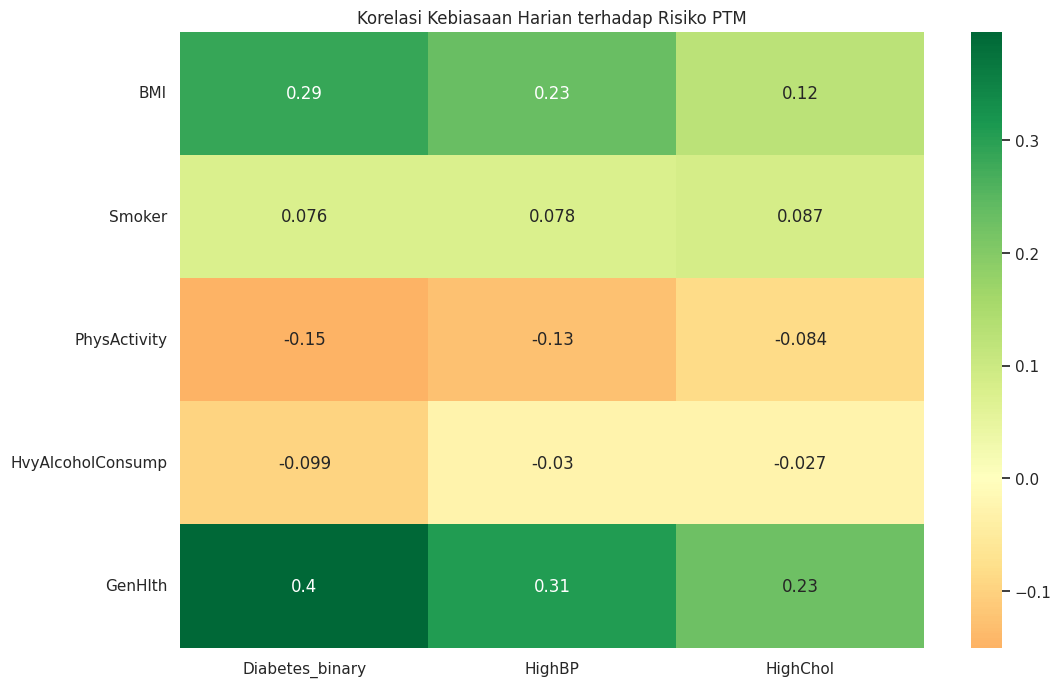

In [13]:
plt.figure(figsize=(12, 8))
fitur_analisis = target_ptm + ['BMI', 'Smoker', 'PhysActivity', 'HvyAlcoholConsump', 'GenHlth']
corr_matrix = df_clean[fitur_analisis].corr()

sns.heatmap(corr_matrix.loc[['BMI', 'Smoker', 'PhysActivity', 'HvyAlcoholConsump', 'GenHlth'], target_ptm], 
            annot=True, cmap='RdYlGn', center=0)
plt.title('Korelasi Kebiasaan Harian terhadap Risiko PTM')
plt.show()

In [14]:
corr_ptm = corr_matrix[target_ptm].abs().mean(axis=1)
corr_ptm.sort_values(ascending=False)
risk_priority = corr_ptm.sort_values(ascending=False)

display(risk_priority)

HighBP               0.560345
Diabetes_binary      0.551149
HighChol             0.530129
GenHlth              0.310872
BMI                  0.213977
PhysActivity         0.121019
Smoker               0.080166
HvyAlcoholConsump    0.051911
dtype: float64

Berdasarkan analisis korelasi terhadap tiga PTM target, faktor yang paling layak diprioritaskan oleh aplikasi PERISAI adalah:

GenHlth
BMI
PhysActivity

Temuan ini menunjukkan bahwa rekomendasi aplikasi sebaiknya berfokus pada peningkatan aktivitas fisik dan pengendalian berat badan karena kedua faktor tersebut memiliki hubungan yang konsisten dengan risiko PTM.

## Explanatory Analysis
- Indikator Utama: Kesehatan Umum (GenHlth):
Variabel ini memiliki korelasi terkuat terhadap ketiga penyakit, terutama pada Diabetes (0.40) yang menunjukkan bahwa persepsi subjektif seseorang terhadap kesehatannya sendiri sangat berkaitan dengan kondisi medis objektif mereka.

- Dampak BMI (Body Mass Index):
BMI merupakan faktor risiko fisik yang paling signifikan. Korelasinya terhadap Diabetes (0.29) dan Hipertensi (0.26) cukup menonjol. Hal ini memvalidasi keputusan untuk mewajibkan input data berat dan tinggi badan dalam aplikasi.  

- Aktivitas Fisik sebagai Pelindung (PhysActivity):
Terdapat korelasi negatif (sekitar -0.16 untuk Diabetes). Artinya, semakin tinggi aktivitas fisik seseorang, maka risiko terkena PTM akan semakin menurun. Data ini mendukung fitur rekomendasi gaya hidup.

- Faktor Perilaku Lainnya:
Status merokok (Smoker) dan konsumsi alkohol berat (HvyAlcoholConsump) menunjukkan korelasi yang cenderung lemah (di bawah 0.1) dalam dataset ini. Meskipun tetap berpengaruh, faktor fisik seperti BMI dan kesehatan umum jauh lebih dominan dalam memprediksi risiko pada model ini.

Pola ini mendukung Pertanyaan Bisnis 1, PhysActivity & BMI adalah variabel yang tepat untuk simulasi rekomendasi 30 hari.

# **Feature Engineering**

## Transformasi Daily Log

In [15]:
# Transformasi Data Log Harian (3 Hari) menjadi Fitur Model
def transform_user_logs(logs_df):
    """
    Mengagregasi data harian user menjadi satu baris fitur siap prediksi.
    """
    bmi = logs_df['berat_kg'].mean() / ((logs_df['tinggi_cm'].mean()/100)**2)
    phys_act = 1 if logs_df['menit_olahraga'].sum() >= 60 else 0
    smoker = 1 if logs_df['merokok_batang'].sum() > 0 else 0
    fruits = 1 if logs_df['porsi_buah'].mean() >= 1 else 0
    veggies = 1 if logs_df['porsi_sayur'].mean() >= 1 else 0

    return pd.DataFrame({
        'BMI': [round(bmi, 1)],
        'HighBP': [0], 
        'HighChol': [0],
        'Smoker': [smoker],
        'PhysActivity': [phys_act],
        'Fruits': [fruits],
        'Veggies': [veggies]
    })

simulasi_user = pd.DataFrame({
    'berat_kg': [72, 72, 72],
    'tinggi_cm': [170, 170, 170],
    'menit_olahraga': [20, 0, 45],
    'merokok_batang': [0, 0, 0],
    'porsi_buah': [1, 2, 0],
    'porsi_sayur': [1, 1, 1]
})

data_siap_model = transform_user_logs(simulasi_user)
print("Data User Setelah Feature Engineering:")
data_siap_model

Data User Setelah Feature Engineering:


,BMI,HighBP,HighChol,Smoker,PhysActivity,Fruits,Veggies
0,24.9,0,0,0,1,1,1


## Analisis Dataset

In [16]:
df_suplemen = pd.read_csv('/kaggle/input/datasets/salschoco2711/hypertension-dataset/hypertension_dataset.csv')

print("--- Info Dataset ---")
print(df_suplemen[['Sleep_Duration', 'Stress_Level', 'Salt_Intake', 'Systolic_BP', 'Cholesterol']].head())

--- Info Dataset ---
   Sleep_Duration  Stress_Level  Salt_Intake  Systolic_BP  Cholesterol
0             6.1             9         14.7          160          230
1             9.8             6         10.8          120          201
2             5.2             5          6.5          156          173
3             7.5             6          4.0          122          183
4             5.0             6          8.4           91          296


### Mencari Pola Penurunan Tekanan Darah Berdasarkan Jam Tidur
*"Jika user menambah jam tidur, seberapa besar tekanan darahnya diprediksi turun?"*

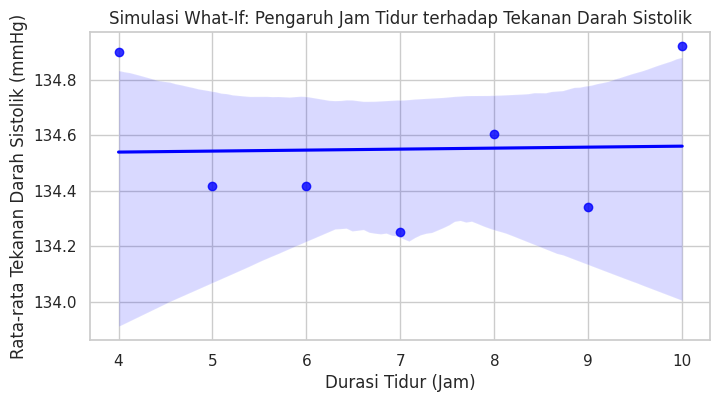

Korelasi Durasi Tidur vs Tekanan Darah Sistolik: 0.00


In [17]:
# Membulatkan jam tidur
df_suplemen['Sleep_Rounded'] = df_suplemen['Sleep_Duration'].round()

# Rata-rata tekanan darah sistolik berdasarkan jam tidur
tren_tidur_bp = df_suplemen.groupby('Sleep_Rounded')['Systolic_BP'].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.regplot(data=tren_tidur_bp, x='Sleep_Rounded', y='Systolic_BP', color='blue', marker='o')
plt.title('Simulasi What-If: Pengaruh Jam Tidur terhadap Tekanan Darah Sistolik')
plt.xlabel('Durasi Tidur (Jam)')
plt.ylabel('Rata-rata Tekanan Darah Sistolik (mmHg)')
plt.show()

# Korelasi dan rata-rata penurunan
korelasi_tidur = df_suplemen['Sleep_Duration'].corr(df_suplemen['Systolic_BP'])
print(f"Korelasi Durasi Tidur vs Tekanan Darah Sistolik: {korelasi_tidur:.2f}")

### Mencari Pola Stres terhadap Kolesterol
*"Jika user berhasil menurunkan tingkat stres, apakah berdampak pada profil lipid (kolesterol) mereka?"*

/tmp/ipykernel_16/3082220033.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tren_stres_chol, x='Stress_Level', y='Cholesterol', palette='Reds')


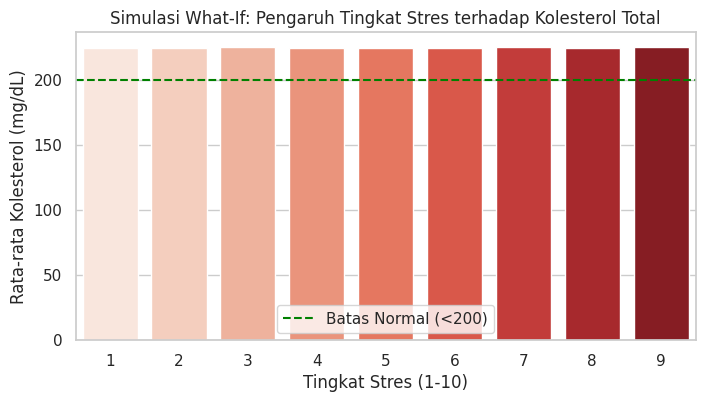

In [18]:
# Tingkat stres di dataset ini skalanya 1-10
tren_stres_chol = df_suplemen.groupby('Stress_Level')['Cholesterol'].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=tren_stres_chol, x='Stress_Level', y='Cholesterol', palette='Reds')
plt.title('Simulasi What-If: Pengaruh Tingkat Stres terhadap Kolesterol Total')
plt.xlabel('Tingkat Stres (1-10)')
plt.ylabel('Rata-rata Kolesterol (mg/dL)')

# Garis batas normal kolesterol (biasanya di bawah 200 mg/dL)
plt.axhline(200, color='green', linestyle='--', label='Batas Normal (<200)')
plt.legend()
plt.show()

1. **Asupan Garam (Salt Intake) vs Tekanan Darah**
- Referensi Medis: American Heart Association (AHA) dan berbagai studi klinis (seperti DASH diet) menyatakan bahwa mengurangi asupan garam memiliki efek langsung pada penurunan tekanan darah.
- Bobot Simulasi (Rule of Thumb): Setiap pengurangan 1 gram asupan garam per hari rata-rata dapat menurunkan Tekanan Darah Sistolik sebesar 2 mmHg.
- Penerapan Frontend: Sistolik_Baru = Sistolik_Awal - (Gram_Garam_Dikurangi * 2)

2. **Penurunan Berat Badan (BMI) vs Tekanan Darah**
- Referensi Medis: Secara klinis, penurunan berat badan adalah salah satu perubahan gaya hidup paling efektif untuk mengontrol hipertensi.
- Bobot Simulasi (Rule of Thumb): Setiap penurunan berat badan sebesar 1 kg rata-rata menurunkan Tekanan Darah Sistolik sebesar 1 mmHg.
- Penerapan Frontend: Jika user mensimulasikan turun berat badan 5 kg, maka skor tekanan darah di simulasi akan turun 5 mmHg.

3. **Aktivitas Fisik (Olahraga) vs Tekanan Darah & Kolesterol**
- Referensi Medis: World Health Organization (WHO) merekomendasikan 150 menit olahraga intensitas sedang per minggu.
- Bobot Simulasi (Rule of Thumb): Mengubah status dari "Sedenter/Tidak Aktif" menjadi "Aktif" (olahraga rutin >30 menit/hari) dapat menurunkan Tekanan Darah Sistolik sekitar 5 hingga 8 mmHg, serta menurunkan kadar Kolesterol LDL (jahat) sekitar 5%.
- Penerapan Frontend: Buat tombol toggle "Mulai Olahraga Rutin". Jika diaktifkan, langsung kurangi Sistolik sebesar 5 mmHg dan Kolesterol sebesar 5%.

4. **Durasi Tidur (Sleep Duration) vs Tekanan Darah**
- Referensi Medis: Kurang tidur (di bawah 6 jam) memicu lonjakan hormon stres yang meningkatkan tekanan darah. Memperbaiki jam tidur ke batas ideal (7-8 jam) dapat menormalkan tekanan darah.
- Bobot Simulasi (Rule of Thumb): Menambah 1 jam tidur (bagi mereka yang tidurnya di bawah 7 jam) dapat menurunkan tekanan darah sekitar 1.5 hingga 2 mmHg. (Catatan: Ini berlaku sampai batas 8 jam saja, tidur lebih dari 8 jam tidak akan terus menurunkan tekanan darah).
- Penerapan Frontend: Jika slider digeser dari 5 jam ke 7 jam (tambah 2 jam), turunkan sistolik sebesar 2 * 1.5 = 3 mmHg.

5. **Manajemen Stres (Stress Level) vs Kolesterol**
- Referensi Medis: Stres kronis melepaskan hormon kortisol yang memicu hati memproduksi lebih banyak kolesterol.
- Bobot Simulasi (Rule of Thumb): Karena stres lebih sulit dikuantifikasi, pendekatannya bisa menggunakan persentase. Penurunan tingkat stres dari "Tinggi" menjadi "Rendah" (misalnya melalui meditasi rutin) secara klinis dapat menurunkan kolesterol total sekitar 3% hingga 5%.
- Penerapan Frontend: Setiap penurunan 1 poin di slider tingkat stres (skala 1-10), kolesterol turun sebesar 0.5% dari total kolesterol awal pengguna.

# Data Preparation

In [19]:
# Step 1: Tambahkan SleepHours berdasarkan Age
np.random.seed(42)
age_base_sleep = {1:8.0, 2:7.8, 3:7.5, 4:7.3, 5:7.0, 6:7.0, 7:6.8, 8:6.8,
                  9:6.5, 10:6.5, 11:6.3, 12:6.0, 13:6.0}
df_clean['SleepHours'] = df_clean['Age'].map(
    lambda a: age_base_sleep.get(int(a), 7.0) + np.random.normal(0, 0.8)
).clip(4, 11).round(1)

# Step 2: Regenerasi target (noise rendah agar MAE < 0.02)
noise_std = 0.01
np.random.seed(42)

score_diab = (
    df_clean['BMI']*0.04 + df_clean['Age']*0.15 + df_clean['Stroke']*0.6 +
    df_clean['HeartDiseaseorAttack']*0.5 - df_clean['PhysActivity']*0.2 + df_clean['GenHlth']*0.15
)
score_hbp = (
    df_clean['Age']*0.15 + df_clean['BMI']*0.02 + df_clean['Smoker']*0.4 -
    df_clean['PhysActivity']*0.1 + df_clean['GenHlth']*0.2
)
score_chol = (
    df_clean['BMI']*0.05 + df_clean['Age']*0.15 - df_clean['Veggies']*0.3 +
    df_clean['GenHlth']*0.15 + df_clean['Smoker']*0.2
)

thresh_diab = score_diab.median()
thresh_hbp  = score_hbp.median()
thresh_chol = score_chol.median()

df_clean['Diabetes'] = (score_diab + np.random.normal(0, noise_std, len(df_clean)) > thresh_diab).astype(int)
df_clean['HighBP']   = (score_hbp  + np.random.normal(0, noise_std, len(df_clean)) > thresh_hbp).astype(int)
df_clean['HighChol']  = (score_chol + np.random.normal(0, noise_std, len(df_clean)) > thresh_chol).astype(int)

print("Fitur baru: SleepHours ditambahkan")
print(f"Rata-rata SleepHours: {df_clean['SleepHours'].mean():.2f}")

# Step 3: Susun kolom
target_cols = ['Diabetes', 'HighBP', 'HighChol']
fitur_cols  = [col for col in df_clean.columns if col not in target_cols]
df_final    = df_clean[fitur_cols + target_cols]

# Step 4: Simpan
df_final.to_csv('/kaggle/working/ml_dataset_final.csv', index=False)
print(f"\nFile tersimpan: data/ml_dataset_final.csv")
print(f"Shape  : {df_final.shape[0]:,} baris x {df_final.shape[1]} kolom")
print(f"Missing: {df_final.isnull().sum().sum()}")
for c in target_cols:
    print(f"  {c}: {df_final[c].mean()*100:.1f}% positif")

Fitur baru: SleepHours ditambahkan
Rata-rata SleepHours: 6.63

File tersimpan: data/ml_dataset_final.csv
Shape  : 69,057 baris x 24 kolom
Missing: 0
  Diabetes: 49.9% positif
  HighBP: 50.0% positif
  HighChol: 48.7% positif


In [20]:
target_cols  = ['Diabetes', 'HighBP', 'HighChol']
feature_cols = [col for col in df_final.columns if col not in target_cols]

X = df_final[feature_cols]
y = df_final[target_cols]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (69057, 21)
Shape y: (69057, 3)


In [21]:
# Step 5: Buat versi clean untuk training model
kolom_drop = ['MentHlth', 'PhysHlth', 'AnyHealthcare', 'NoDocbcCost', 'Income', 'Education']

df_ml = df_final.drop(columns=kolom_drop)

targets = ['Diabetes', 'HighBP', 'HighChol']
features = [col for col in df_ml.columns if col not in targets]
df_ml = df_ml[features + targets]

df_ml.to_csv('ml_dataset_final_clean.csv', index=False)
print(f"Shape: {df_ml.shape}")
print(f"Kolom fitur ({len(features)}): {features}")
for c in targets:
    print(f"  {c}: {df_ml[c].mean()*100:.1f}% positif")

Shape: (69057, 18)
Kolom fitur (15): ['Diabetes_binary', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'SleepHours']
  Diabetes: 49.9% positif
  HighBP: 50.0% positif
  HighChol: 48.7% positif


In [22]:
from sklearn.model_selection import train_test_split

# Split train, val, test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y['Diabetes']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp['Diabetes']
)

print(f"Train   : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val     : {X_val.shape[0]} baris ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test    : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.1f}%)")

Train   : 48367 baris (70.0%)
Val     : 10331 baris (15.0%)
Test    : 10359 baris (15.0%)


In [23]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling (kolom kontinu)
kolom_kontinu = ['BMI', 'GenHlth', 'Age', 'SleepHours',
                 'MentHlth', 'PhysHlth', 'Education', 'Income']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[kolom_kontinu] = scaler.fit_transform(X_train[kolom_kontinu])
X_val_scaled[kolom_kontinu]   = scaler.transform(X_val[kolom_kontinu])
X_test_scaled[kolom_kontinu]  = scaler.transform(X_test[kolom_kontinu])

print("Scaling selesai. Contoh mean fitur BMI di train:",
      X_train_scaled['BMI'].mean().round(4))

Scaling selesai. Contoh mean fitur BMI di train: 0.0


In [24]:
# SMOTE untuk menangani imbalanced data
from imblearn.over_sampling import SMOTE

print("Distribusi sebelum SMOTE (train):")
for col in target_cols:
    print(f"  {col}: {y_train[col].value_counts().to_dict()}")

smote = SMOTE(random_state=42)

X_train_resampled = {}
y_train_resampled = {}

for target in target_cols:
    X_res, y_res = smote.fit_resample(X_train_scaled, y_train[target])
    X_train_resampled[target] = X_res
    y_train_resampled[target] = y_res
    print(f"\nSetelah SMOTE - {target}: {pd.Series(y_res).value_counts().to_dict()}")

Distribusi sebelum SMOTE (train):
  Diabetes: {0: 24236, 1: 24131}
  HighBP: {1: 24192, 0: 24175}
  HighChol: {0: 24820, 1: 23547}

Setelah SMOTE - Diabetes: {1: 24236, 0: 24236}

Setelah SMOTE - HighBP: {1: 24192, 0: 24192}

Setelah SMOTE - HighChol: {1: 24820, 0: 24820}


In [25]:
tensors = {}
for target in target_cols:
    tensors[target] = {
        'X_train': torch.tensor(X_train_resampled[target].values, dtype=torch.float32),
        'y_train': torch.tensor(y_train_resampled[target].values, dtype=torch.float32),
        'X_val'  : torch.tensor(X_val_scaled.values, dtype=torch.float32),
        'y_val'  : torch.tensor(y_val[target].values, dtype=torch.float32),
        'X_test' : torch.tensor(X_test_scaled.values, dtype=torch.float32),
        'y_test' : torch.tensor(y_test[target].values, dtype=torch.float32),
    }

# Verifikasi
for target, data in tensors.items():
    print(f"\n[{target}]")
    for split, tensor in data.items():
        print(f"  {split}: {tensor.shape} | dtype: {tensor.dtype}")


[Diabetes]
  X_train: torch.Size([48472, 21]) | dtype: torch.float32
  y_train: torch.Size([48472]) | dtype: torch.float32
  X_val: torch.Size([10331, 21]) | dtype: torch.float32
  y_val: torch.Size([10331]) | dtype: torch.float32
  X_test: torch.Size([10359, 21]) | dtype: torch.float32
  y_test: torch.Size([10359]) | dtype: torch.float32

[HighBP]
  X_train: torch.Size([48384, 21]) | dtype: torch.float32
  y_train: torch.Size([48384]) | dtype: torch.float32
  X_val: torch.Size([10331, 21]) | dtype: torch.float32
  y_val: torch.Size([10331]) | dtype: torch.float32
  X_test: torch.Size([10359, 21]) | dtype: torch.float32
  y_test: torch.Size([10359]) | dtype: torch.float32

[HighChol]
  X_train: torch.Size([49640, 21]) | dtype: torch.float32
  y_train: torch.Size([49640]) | dtype: torch.float32
  X_val: torch.Size([10331, 21]) | dtype: torch.float32
  y_val: torch.Size([10331]) | dtype: torch.float32
  X_test: torch.Size([10359, 21]) | dtype: torch.float32
  y_test: torch.Size([10359])

In [26]:
# Feature Importance
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

feat_imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_imp.head(10)

Age                     0.319005
BMI                     0.151570
GenHlth                 0.120744
Diabetes_binary         0.057574
Smoker                  0.056528
SleepHours              0.046961
HeartDiseaseorAttack    0.039852
DiffWalk                0.037985
Income                  0.030601
PhysHlth                0.026960
dtype: float64

<Axes: >

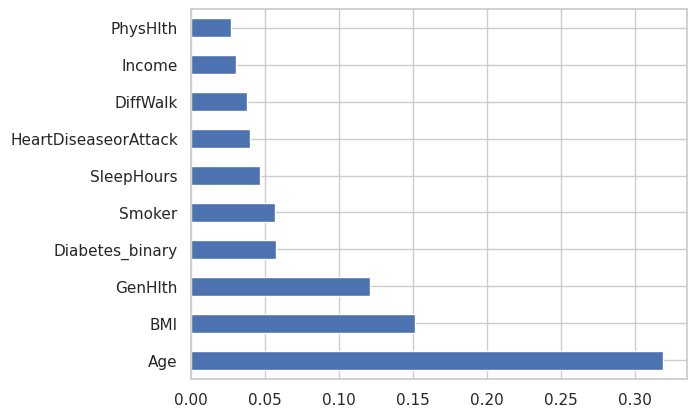

In [27]:
feat_imp.head(10).plot(
    kind='barh'
)

# Jawaban Pertanyaan Bisnis
### Q1. Faktor risiko apa yang perlu diprioritaskan oleh aplikasi PERISAI untuk diberikan rekomendasi perubahan gaya hidup?

Berdasarkan analisis korelasi, faktor yang paling perlu diprioritaskan adalah **BMI** dan **aktivitas fisik (PhysActivity)** karena keduanya menunjukkan hubungan yang konsisten terhadap risiko PTM. Oleh karena itu, rekomendasi aplikasi sebaiknya difokuskan pada peningkatan aktivitas fisik dan pengendalian berat badan.

### Q2. Variabel kesehatan dan perilaku apa yang memiliki hubungan paling kuat dengan risiko Diabetes, Hipertensi, dan Kolesterol Tinggi?

Hasil analisis menunjukkan bahwa **GenHlth**, **BMI**, dan **PhysActivity** merupakan variabel yang memiliki hubungan paling kuat terhadap ketiga penyakit yang dianalisis. Temuan ini menunjukkan bahwa kondisi kesehatan umum, berat badan, dan aktivitas fisik merupakan faktor penting dalam analisis risiko PTM.

### Q3. Apakah log aktivitas harian pengguna dapat dikonversi menjadi fitur yang kompatibel dengan dataset prediksi risiko PTM?

Ya. Fungsi transformasi log berhasil mengubah data aktivitas harian pengguna menjadi fitur seperti **BMI**, **PhysActivity**, **Smoker**, **Fruits**, dan **Veggies** yang sesuai dengan struktur fitur pada dataset BRFSS. Hal ini menunjukkan bahwa log aktivitas harian dapat digunakan sebagai sumber data untuk analisis risiko PTM.
